In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from os import listdir
from os.path import isfile, join
from matplotlib.ticker import FuncFormatter

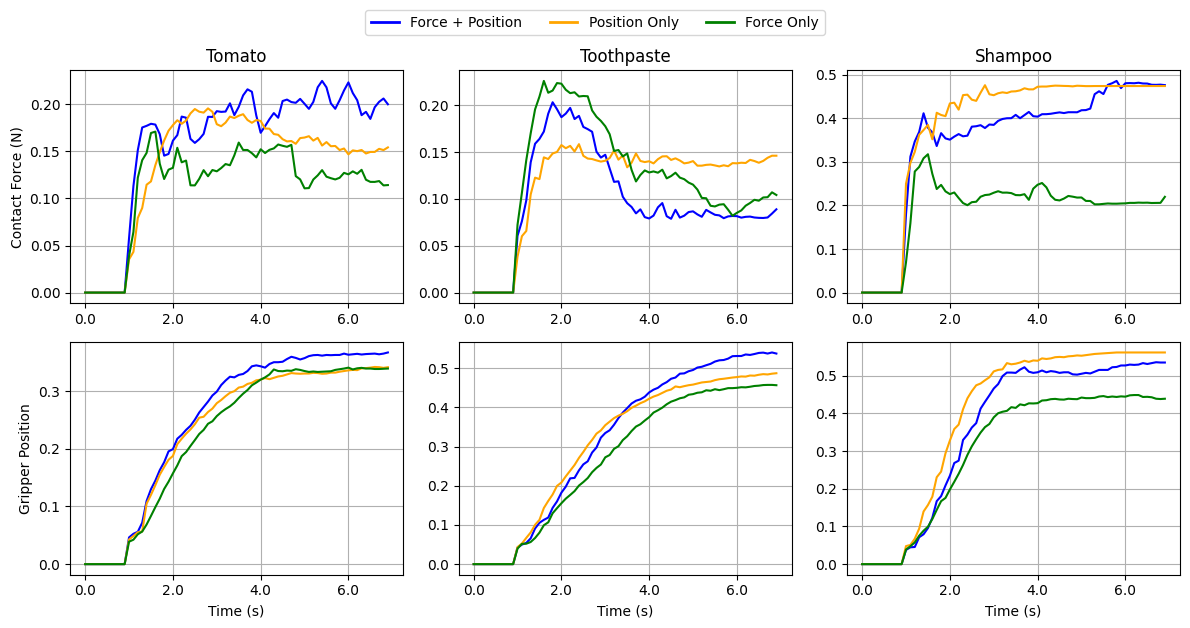

In [ ]:
def calc_averaged_force(data_path, max_length=500, padding=10, output_length=70):
    """Calculate averaged force profiles from multiple experiment runs.
    
    Args:
        data_path: Path to directory containing .npy files
        max_length: Maximum timesteps to consider
        padding: Initial padding before contact
        output_length: Length of output averaged signal
        
    Returns:
        np.array: Averaged force profile
    """
    files = [f for f in listdir(data_path) if isfile(join(data_path, f))]
    force_sum = np.zeros(max_length)
    
    for file in files:
        data = np.load(join(data_path, file), allow_pickle=True)
        
        # Find first contact point
        for i in range(len(data)):
            if data[i, -1] > 0:  # Check force value
                # Pad and align the signal
                padded_data = np.concatenate([
                    np.zeros(padding),
                    data[i:, -1],
                    np.full(max_length - padding - len(data[i:]), data[-1, -1])
                ])
                force_sum += padded_data
                break
                
    return force_sum[:output_length] / len(files)

def calc_averaged_position(data_path, max_length=500, padding=10, output_length=70, threshold=0.03):
    """Calculate averaged gripper position profiles from multiple runs.
    
    Args:
        data_path: Path to directory containing .npy files
        max_length: Maximum timesteps to consider
        padding: Initial padding before movement
        output_length: Length of output averaged signal
        threshold: Position change threshold to detect movement
        
    Returns:
        np.array: Averaged position profile
    """
    files = [f for f in listdir(data_path) if isfile(join(data_path, f))]
    position_sum = np.zeros(max_length)
    
    for file in files:
        data = np.load(join(data_path, file), allow_pickle=True)
        
        # Find first significant movement
        for i in range(len(data)):
            if data[i, -2] > threshold:  # Check position value
                # Pad and align the signal
                padded_data = np.concatenate([
                    np.zeros(padding),
                    data[i:, -2],
                    np.full(max_length - padding - len(data[i:]), data[-1, -2])
                ])
                position_sum += padded_data
                break
                
    return position_sum[:output_length] / len(files)

def create_comparison_plots():
    """Generate comparison plots for all objects and sensor configurations."""
    log_path = '/home/hyperdog/octo/logs/'
    objects = ['tomato', 'toothpaste', 'shampoo']
    configs = ['force_and_position', 'position', 'force']
    colors = ['blue', 'orange', 'green']
    
    fig, axs = plt.subplots(2, 3, figsize=(12, 6))
    
    # Plot force and position data for each object
    for col, obj in enumerate(objects):
        # Force plots (top row)
        for config, color in zip(configs, colors):
            path = join(log_path, obj, config)
            axs[0, col].plot(
                calc_averaged_force(path),
                color=color,
                label=config.replace('_', ' ')
            )
        
        # Position plots (bottom row)
        for config, color in zip(configs, colors):
            path = join(log_path, obj, config)
            axs[1, col].plot(
                calc_averaged_position(path),
                color=color,
                label=config.replace('_', ' ')
            )
    
    # Axis labels and formatting
    for ax in axs[:, 0]:
        ax.set_ylabel('Contact Force (N)')
    axs[1, 0].set_ylabel('Gripper Position')
    
    for ax in axs[-1]:
        ax.set_xlabel('Time (s)')
    
    # Time axis formatting
    def time_formatter(x, pos):
        return f'{x / 10:.1f}'  # Convert timesteps to seconds
    
    for ax in axs.flatten():
        ax.xaxis.set_major_formatter(FuncFormatter(time_formatter))
        ax.grid(True)
    
    # Column titles
    for ax, title in zip(axs[0], ['Tomato', 'Toothpaste', 'Shampoo']):
        ax.set_title(title)
    
    # Legend
    legend_elements = [
        plt.Line2D([0], [0], color='blue', lw=2, label='Force + Position'),
        plt.Line2D([0], [0], color='orange', lw=2, label='Position Only'), 
        plt.Line2D([0], [0], color='green', lw=2, label='Force Only')
    ]
    
    fig.legend(
        handles=legend_elements,
        loc='upper center',
        ncol=3,
        bbox_to_anchor=(0.5, 1.05))
    
    plt.tight_layout()
    plt.show()

create_comparison_plots()